# Figure S12: Cross-vendor correspondence pre/post harmonization across all microstructural metrics

Figure S12 extends the Figure 5A idea to all config-listed microstructural metrics, split into software panels (DIPY, AMICO, TORTOISE, DSI Studio).


In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s12_dir <- fs::path(project_root, "figures", "Supplement", "FigureS12")
fs::dir_create(figure_s12_dir, recurse = TRUE)

age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
if (!file.exists(age_effect_file)) stop("Missing assembled age-effect file: ", age_effect_file)

df_age_all <- readRDS(age_effect_file)
required_cols <- c("bundle", "metric", "qc_metric", "source", "output_type", "scanner_manufacturer", "age_effect_size")
missing_cols <- setdiff(required_cols, names(df_age_all))
if (length(missing_cols) > 0) {
  stop("Assembled age-effect data missing required columns: ", paste(missing_cols, collapse = ", "))
}



Warning message in geom_hline(data = separator_df, aes(yintercept = Inf), inherit.aes = FALSE, :
“Ignoring unknown parameters: `inherit.aes`”
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS12/S12_cross_vendor_correspondence_pre_post_harmonization.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS12/S12_cross_vendor_correspondence_pre_post_harmonization.png



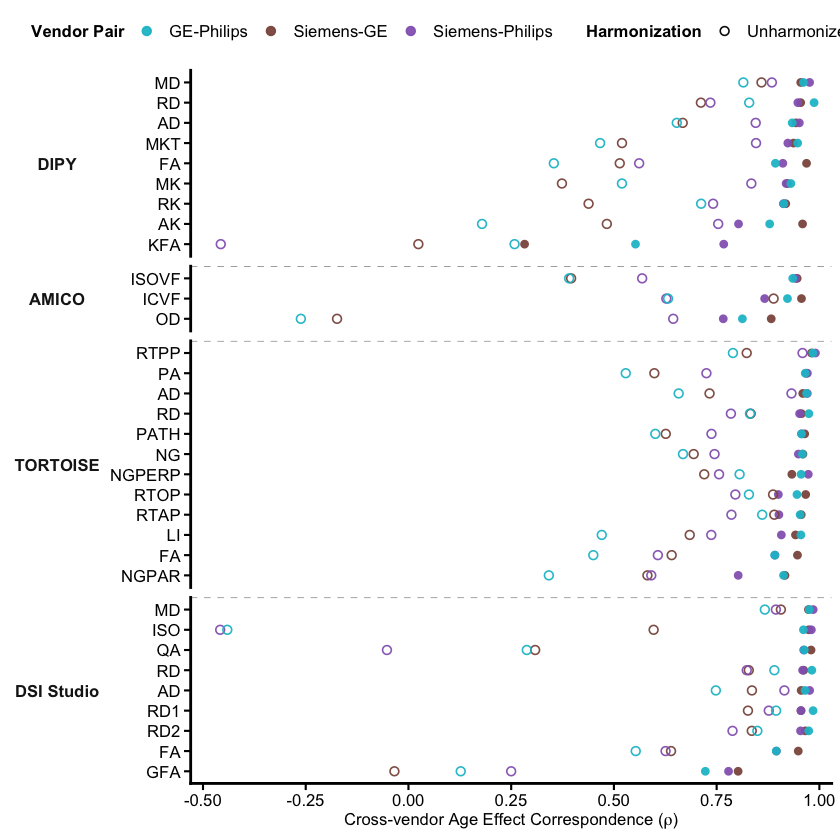

In [ ]:
metrics_keep <- trimws(as.character(config$microstructural_metrics))
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")
pair_colors <- c("Siemens-GE" = "#8c564b", "Siemens-Philips" = "#9467bd", "GE-Philips" = "#17becf")

pair_defs <- tibble::tribble(
  ~pair_label, ~vendor_1, ~vendor_2,
  "Siemens-GE", "Siemens", "GE",
  "Siemens-Philips", "Siemens", "Philips",
  "GE-Philips", "GE", "Philips"
)

metric_meta <- tibble(metric = metrics_keep) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    metric_label = ifelse(
      str_detect(metric, "_"),
      str_to_upper(str_remove(metric, "^[^_]+_")),
      str_to_upper(metric)
    )
  ) %>%
  filter(software %in% software_order)

df_vendor <- df_age_all %>%
  filter(
    output_type == "vendorwise",
    qc_metric == "no_quality",
    source %in% c("raw", "harmonized"),
    scanner_manufacturer %in% c("Siemens", "GE", "Philips"),
    metric %in% metric_meta$metric,
    !is.na(bundle),
    !is.na(age_effect_size)
  ) %>%
  transmute(
    bundle = as.character(bundle),
    metric = as.character(metric),
    source_pretty = if_else(source == "raw", "Unharmonized", "Harmonized"),
    scanner_manufacturer = as.character(scanner_manufacturer),
    age_effect_size = as.numeric(age_effect_size)
  )

if (nrow(df_vendor) == 0) stop("No rows for FigureS12 (vendorwise age effects).")

panel_df <- df_vendor %>%
  group_by(source_pretty, metric) %>%
  group_modify(function(grp, key) {
    pair_defs %>% mutate(
      rho = purrr::pmap_dbl(list(vendor_1, vendor_2), function(v1, v2) {
        d1 <- grp %>% filter(scanner_manufacturer == v1) %>% select(bundle, age_effect_size)
        d2 <- grp %>% filter(scanner_manufacturer == v2) %>% select(bundle, age_effect_size)
        j <- inner_join(d1, d2, by = "bundle")
        if (nrow(j) < 3) return(NA_real_)
        cor(j$age_effect_size.x, j$age_effect_size.y, method = "spearman", use = "pairwise.complete.obs")
      }),
      n_overlap = purrr::pmap_int(list(vendor_1, vendor_2), function(v1, v2) {
        d1 <- grp %>% filter(scanner_manufacturer == v1) %>% select(bundle)
        d2 <- grp %>% filter(scanner_manufacturer == v2) %>% select(bundle)
        nrow(inner_join(d1, d2, by = "bundle"))
      })
    )
  }) %>%
  ungroup() %>%
  left_join(metric_meta, by = "metric") %>%
  mutate(source_pretty = factor(source_pretty, levels = c("Unharmonized", "Harmonized"))) %>%
  filter(!is.na(rho), !is.na(software), !is.na(metric_label))

if (nrow(panel_df) == 0) stop("FigureS12 produced no usable rho values.")

metric_rank <- panel_df %>%
  filter(source_pretty == "Harmonized") %>%
  group_by(software, metric, metric_label) %>%
  summarise(avg_rho_harmonized = mean(rho, na.rm = TRUE), .groups = "drop") %>%
  mutate(software = factor(software, levels = software_order)) %>%
  arrange(software, avg_rho_harmonized)

metric_levels <- metric_rank %>%
  mutate(metric_plot = paste(software, metric_label, metric, sep = "___")) %>%
  pull(metric_plot)

panel_df <- panel_df %>%
  mutate(metric_plot = paste(software, metric_label, metric, sep = "___")) %>%
  filter(metric_plot %in% metric_levels) %>%
  mutate(
    metric_plot = factor(metric_plot, levels = metric_levels),
    software = factor(software, levels = software_order)
  )

separator_df <- tibble(
  software = factor(software_order[-1], levels = software_order)
)

p_s12 <- ggplot(panel_df, aes(x = rho, y = metric_plot)) +
  geom_point(
    aes(color = pair_label, shape = source_pretty),
    size = 2.0,
    stroke = 0.7,
    alpha = 0.95
  ) +
  geom_hline(
    data = separator_df,
    aes(yintercept = Inf),
    inherit.aes = FALSE,
    color = "grey50",
    linetype = "dashed",
    linewidth = 0.35
  ) +
  facet_grid(rows = vars(software), cols = vars(), scales = "free_y", space = "free_y", switch = "y") +
  scale_color_manual(values = pair_colors, name = "Vendor Pair") +
  scale_shape_manual(values = c("Unharmonized" = 1, "Harmonized" = 16), name = "Harmonization") +
  scale_x_continuous(limits = c(-0.5, 1), breaks = seq(-1, 1, by = 0.25), expand = expansion(mult = c(0.02, 0.02))) +
  scale_y_discrete(labels = function(x) vapply(strsplit(x, "___", fixed = TRUE), function(z) z[2], character(1))) +
  labs(x = expression("Cross-Vendor Age Effect Correspondence (" * rho * ")"), y = NULL, title = NULL) +
  make_theme_pub(
    style = plot_style,
    legend_position = "top",
    axis_title_pt = 10,
    axis_text_pt = 10,
    legend_title_pt = 10,
    legend_text_pt = 10,
    base_size_pt = 10
  ) +
  theme(
    text = element_text(family = font_family_use),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.spacing.y = grid::unit(6, "pt"),
    strip.placement = "outside",
    strip.background = element_blank(),
    strip.text.y.left = element_text(angle = 0, face = "bold", size = 10),
    axis.text.y = element_text(size = 10, colour = "black"),
    legend.box = "horizontal"
  )

p_s12

save_plot_outputs(
  plot_obj = p_s12,
  stub = "S12_cross_vendor_correspondence_pre_post_harmonization",
  out_dir = figure_s12_dir,
  width_in = 10,
  height_in = 13
)
